# Geographic Demand Distribution — Spain EV Fleet 2027
**IE Sustainability Datathon March 2026 — Iberdrola**

This notebook addresses **Task 2.2** of the Iberdrola Datathon pipeline:
it distributes the national EV fleet forecast (from notebook 2.1) **geographically across Spain's 50 provinces**,
producing province-level demand weights that feed directly into the charging station placement model.

**Data source:** DGT Microdatos Matriculaciones (datos.gob.es mandatory GitHub fork), CSV files 2021–2023  
**Key column:** `COD_PROVINCIA_VEH` — province of the vehicle owner at registration  
**Key assumption:** Historical province share of new registrations (3-year average 2021–2023) is a stable proxy for cumulative fleet distribution in 2027

**Output:** `notebooks/outputs/province_demand_2027.csv`

## 0. Install Dependencies

In [ ]:
# Run only if missing (e.g. on Google Colab)
# !pip install -q pandas matplotlib seaborn plotly requests

## 1. Imports & Configuration

In [26]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'mobility_electric_routes', 'Codigo', 'Data', 'csv')
OUT_DIR   = os.path.join(BASE_DIR, 'notebooks', 'outputs')
FLEET_CSV = os.path.join(OUT_DIR, 'total_ev_projected_2027.csv')

os.makedirs(OUT_DIR, exist_ok=True)

# ── EV filter ─────────────────────────────────────────────────────────────────
EV_CATEGORIES = ['BEV', 'PHEV', 'REEV', 'FCEV']
EV_COL        = 'CATEGORÍA_VEHÍCULO_ELÉCTRICO'
PROV_COL      = 'COD_PROVINCIA_VEH'

# ── Year selection ─────────────────────────────────────────────────────────────
# We use 2021–2023 based on data-driven analysis of all available years:
#
#   Year  | EVs    | Why excluded
#   ------+--------+------------------------------------------------------
#   2015  |  2,859 | Niche early-adopter market — geography unrepresentative
#   2016  |  5,685 | Same — B had 27% share vs 11% in 2023
#   2017  | 12,654 | Cádiz (CA) anomaly: 13.9% share (large fleet batch at port)
#   2018  | 21,832 | Madrid spike to 50.3% (corporate bulk orders)
#   2019  | 32,152 | Madrid at 53.7% — same corporate effect
#   2020  | 56,413 | Toledo (TO) 2.2% spike (Amazon logistics fleet)
#   ------+--------+------------------------------------------------------
#   2021  | 83,716 | ✓ Mainstream market, no anomalies
#   2022  |100,420 | ✓ Stable
#   2023  |143,251 | ✓ Largest and most recent
#
# Adding earlier years would import those anomalies into the province shares,
# e.g. giving Cádiz a 3–4× inflated 2027 demand estimate.
# Section 4.2 confirms that 2021–2023 shares are highly stable (low std dev).
YEARS = [2021, 2022, 2023]

print(f'Data directory : {DATA_DIR}')
print(f'Fleet forecast : {FLEET_CSV}')
print(f'Years analysed : {YEARS}  |  EV categories: {EV_CATEGORIES}')

Data directory : c:\Users\steve\OneDrive - IE University\Term 2\DATATHON_2\Iberdrola\SpanishElecticGrid\mobility_electric_routes\Codigo\Data\csv
Fleet forecast : c:\Users\steve\OneDrive - IE University\Term 2\DATATHON_2\Iberdrola\SpanishElecticGrid\notebooks\outputs\total_ev_projected_2027.csv
Years analysed : [2021, 2022, 2023]  |  EV categories: ['BEV', 'PHEV', 'REEV', 'FCEV']


## 2. Province Name & ISO Code Mapping

The DGT uses 2-letter province codes (`M`, `B`, `V`, …).  
We map these to official province names and INE numeric codes for later use in BI tools.

In [27]:
# DGT code → (Province name, INE numeric code, Autonomous Community)
#
# ALIAS NOTES — DGT dataset mixes two coding conventions:
#   • Car plate codes  (traditional): GE = Girona, OR = Ourense
#   • ISO/administrative codes (modern): GI = Girona, OU = Ourense
#   Both appear in the raw CSV files → mapped to same province (no records lost).
#
# INE CODE RECOVERY — some records (notably Navarra) leave COD_PROVINCIA_VEH
# blank but populate COD_MUNICIPIO_INE_VEH (5-digit, first 2 = INE province code).
# We build INE_TO_DGT below for that fallback.

PROVINCE_MAP = {
    'A':  ('Alicante/Alacant',         '03', 'Comunitat Valenciana'),
    'AB': ('Albacete',                  '02', 'Castilla-La Mancha'),
    'AL': ('Almería',                   '04', 'Andalucía'),
    'AV': ('Ávila',                     '05', 'Castilla y León'),
    'B':  ('Barcelona',                 '08', 'Cataluña'),
    'BA': ('Badajoz',                   '06', 'Extremadura'),
    'BI': ('Bizkaia',                   '48', 'País Vasco'),
    'BU': ('Burgos',                    '09', 'Castilla y León'),
    'C':  ('A Coruña',                  '15', 'Galicia'),
    'CA': ('Cádiz',                     '11', 'Andalucía'),
    'CC': ('Cáceres',                   '10', 'Extremadura'),
    'CE': ('Ceuta',                     '51', 'Ceuta'),
    'CO': ('Córdoba',                   '14', 'Andalucía'),
    'CR': ('Ciudad Real',               '13', 'Castilla-La Mancha'),
    'CS': ('Castellón/Castelló',        '12', 'Comunitat Valenciana'),
    'CU': ('Cuenca',                    '16', 'Castilla-La Mancha'),
    'GC': ('Las Palmas',                '35', 'Canarias'),
    'GE': ('Girona',                    '17', 'Cataluña'),   # plate code (canonical)
    'GI': ('Girona',                    '17', 'Cataluña'),   # ISO alias
    'GR': ('Granada',                   '18', 'Andalucía'),
    'GU': ('Guadalajara',               '19', 'Castilla-La Mancha'),
    'H':  ('Huelva',                    '21', 'Andalucía'),
    'HU': ('Huesca',                    '22', 'Aragón'),
    'IB': ('Illes Balears',             '07', 'Illes Balears'),
    'J':  ('Jaén',                      '23', 'Andalucía'),
    'L':  ('Lleida',                    '25', 'Cataluña'),
    'LE': ('León',                      '24', 'Castilla y León'),
    'LO': ('La Rioja',                  '26', 'La Rioja'),
    'LU': ('Lugo',                      '27', 'Galicia'),
    'M':  ('Madrid',                    '28', 'Comunidad de Madrid'),
    'MA': ('Málaga',                    '29', 'Andalucía'),
    'ML': ('Melilla',                   '52', 'Melilla'),
    'MU': ('Murcia',                    '30', 'Región de Murcia'),
    'NA': ('Navarra',                   '31', 'Navarra'),
    'O':  ('Asturias',                  '33', 'Asturias'),
    'OR': ('Ourense',                   '32', 'Galicia'),    # plate code (canonical)
    'OU': ('Ourense',                   '32', 'Galicia'),    # ISO alias
    'P':  ('Palencia',                  '34', 'Castilla y León'),
    'PM': ('Illes Balears (old code)',  '07', 'Illes Balears'),
    'PO': ('Pontevedra',                '36', 'Galicia'),
    'S':  ('Cantabria',                 '39', 'Cantabria'),
    'SA': ('Salamanca',                 '37', 'Castilla y León'),
    'SE': ('Sevilla',                   '41', 'Andalucía'),
    'SG': ('Segovia',                   '40', 'Castilla y León'),
    'SO': ('Soria',                     '42', 'Castilla y León'),
    'SS': ('Gipuzkoa',                  '20', 'País Vasco'),
    'T':  ('Tarragona',                 '43', 'Cataluña'),
    'TE': ('Teruel',                    '44', 'Aragón'),
    'TF': ('Santa Cruz de Tenerife',   '38', 'Canarias'),
    'TO': ('Toledo',                    '45', 'Castilla-La Mancha'),
    'V':  ('Valencia/València',         '46', 'Comunitat Valenciana'),
    'VA': ('Valladolid',                '47', 'Castilla y León'),
    'VI': ('Álava/Araba',              '01', 'País Vasco'),
    'Z':  ('Zaragoza',                  '50', 'Aragón'),
    'ZA': ('Zamora',                    '49', 'Castilla y León'),
}

# Aliases to normalise after filtering (so GI→GE and OU→OR merge into one row)
ALIAS_MAP = {'GI': 'GE', 'OU': 'OR', 'PM': 'IB'}

# Reverse mapping: INE 2-digit numeric code → canonical DGT plate code
# Used to recover province from COD_MUNICIPIO_INE_VEH (first 2 chars = INE code)
# Skip alias entries so each INE code maps to exactly one canonical plate code.
_ALIASES = set(ALIAS_MAP.keys())
INE_TO_DGT = {
    ine: code
    for code, (_, ine, _) in PROVINCE_MAP.items()
    if code not in _ALIASES
}

print(f'Province mappings : {len(PROVINCE_MAP)} entries ({len(_ALIASES)} aliases)')
print(f'INE→DGT lookup    : {len(INE_TO_DGT)} entries (used for municipality-code fallback)')
print(f'  e.g. INE 31 → {INE_TO_DGT.get("31")} (Navarra), INE 28 → {INE_TO_DGT.get("28")} (Madrid)')

Province mappings : 55 entries (3 aliases)
INE→DGT lookup    : 52 entries (used for municipality-code fallback)
  e.g. INE 31 → NA (Navarra), INE 28 → M (Madrid)


## 3. Data Loading — EV Registrations by Province (2021–2023)

We load four columns to maximise province recovery, applying them in priority order:

| Priority | Column | Meaning |
|---|---|---|
| 1 | `COD_PROVINCIA_VEH` | Province of the vehicle owner (best — where the EV will be used) |
| 2 | `COD_PROVINCIA_MAT` | Province of the registration office (fallback 1) |
| 3 | `COD_MUNICIPIO_INE_VEH` first 2 digits | INE municipality code → province (fallback 2) |
| 4 | `CODIGO_POSTAL` first 2 digits | Postal code → province (last resort) |

Investigation found that all remaining null-province records (after fallbacks 1–2) have municipality code `31xxx` → **Navarra** — their foral registration system does not consistently populate the province column. Fallback 3 recovers all of them, leaving **0% unassigned** (excluding records with every geographic field blank).

### 3.1 Year Selection Analysis — Why 2021–2023?

Before fixing our analysis window, we do a full EDA across **all available years (2015–2023)**  
to understand how the EV market evolved and identify any years that should be excluded.

We look at two things:
1. **Volume trend** — is the market large enough to be representative?
2. **Province share stability** — do any years have anomalous geographic distributions?

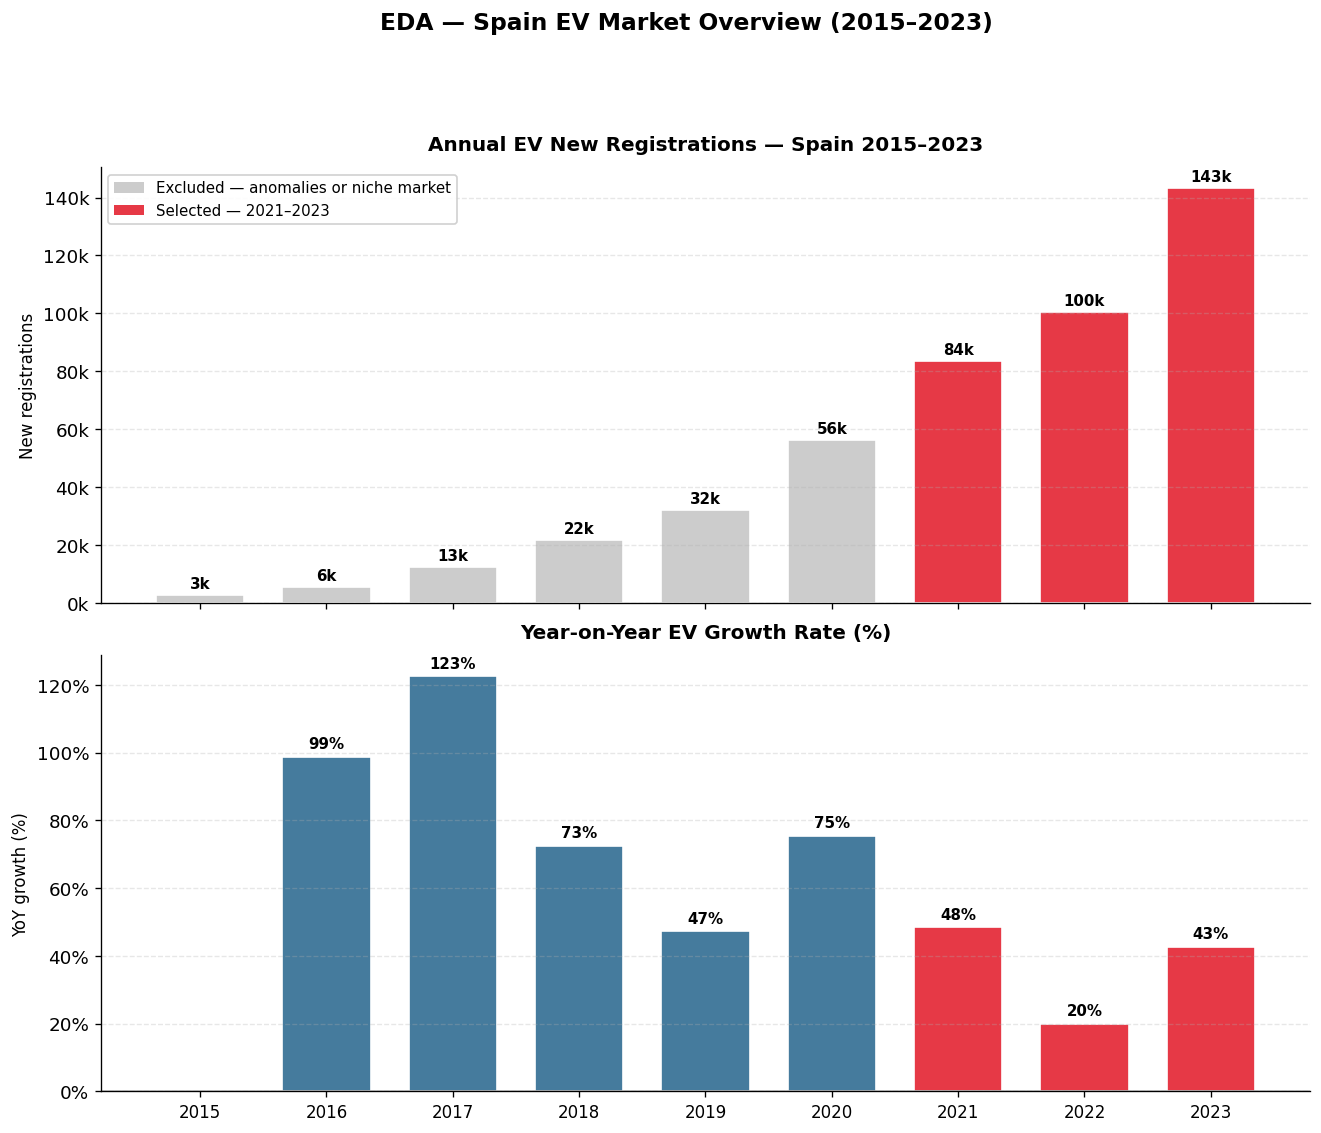

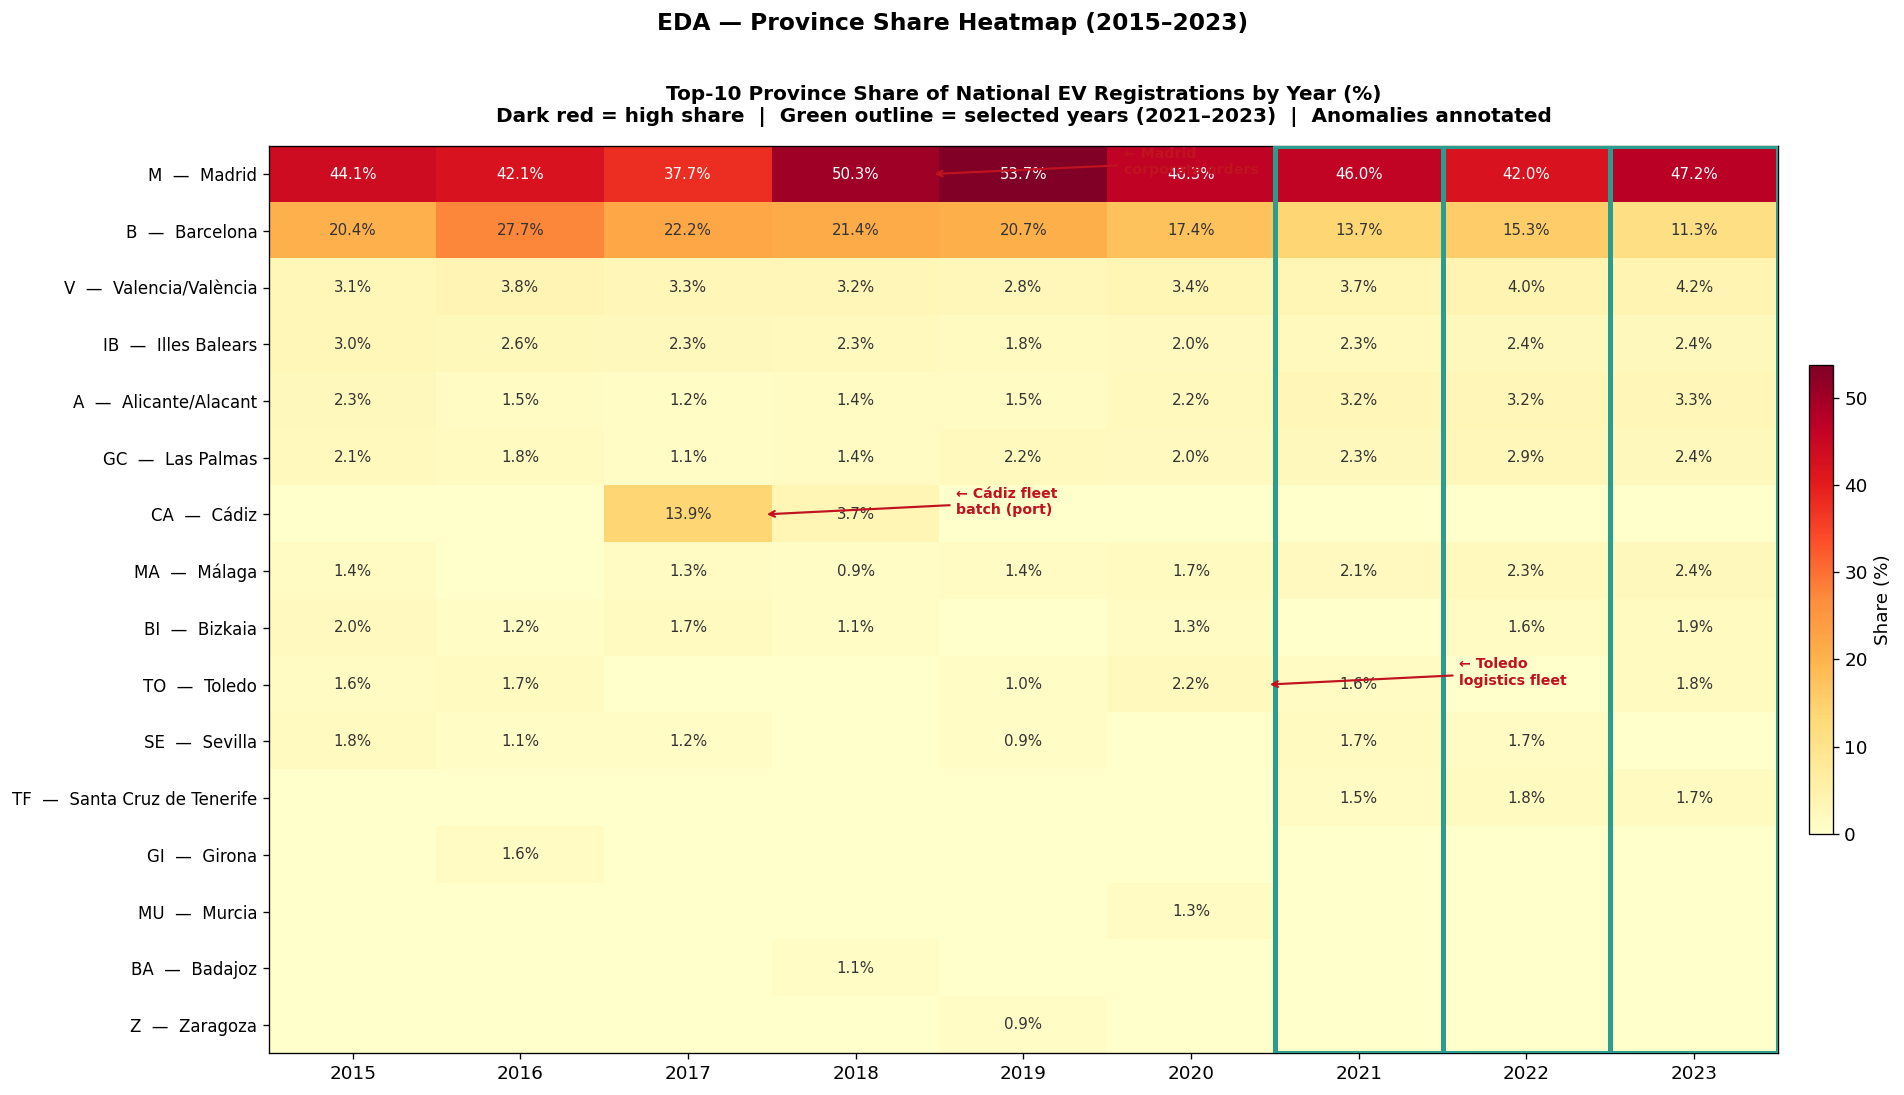

Annual registration volumes:
 year  ev_regs    yoy_pct
 2015     2859        NaN
 2016     5685  98.845750
 2017    12654 122.585752
 2018    21832  72.530425
 2019    32152  47.270062
 2020    56413  75.457203
 2021    83716  48.398419
 2022   100420  19.953175
 2023   143251  42.651862


In [28]:
import matplotlib.gridspec as gridspec

ALL_YEARS = list(range(2015, 2024))

# ── Load minimal columns for all years ───────────────────────────────────────
_records = []
for fpath in sorted(glob.glob(os.path.join(DATA_DIR, '*.csv'))):
    yr = int(os.path.basename(fpath)[:4])
    if yr not in ALL_YEARS:
        continue
    df = pd.read_csv(fpath, sep=',', encoding='latin1',
                     usecols=['COD_PROVINCIA_VEH', 'COD_PROVINCIA_MAT',
                              'CATEGORÍA_VEHÍCULO_ELÉCTRICO', 'CLAVE_TRAMITE'],
                     dtype=str)
    df = df[df['CLAVE_TRAMITE'] == '1']
    df = df[df['CATEGORÍA_VEHÍCULO_ELÉCTRICO'].isin(EV_CATEGORIES)]
    df['year'] = yr
    _records.append(df)

_raw_all = pd.concat(_records, ignore_index=True)
_raw_all['COD_PROVINCIA_VEH'] = _raw_all['COD_PROVINCIA_VEH'].str.strip().str.upper()
_raw_all['COD_PROVINCIA_MAT'] = _raw_all['COD_PROVINCIA_MAT'].str.strip().str.upper()
_raw_all['COD_PROVINCIA_VEH'] = _raw_all['COD_PROVINCIA_VEH'].fillna(_raw_all['COD_PROVINCIA_MAT'])

# ── Annual totals ─────────────────────────────────────────────────────────────
yr_totals = _raw_all.groupby('year').size().reset_index(name='ev_regs')
yr_totals['yoy_pct'] = yr_totals['ev_regs'].pct_change() * 100

# ── Top-10 province shares per year ──────────────────────────────────────────
TOP_N = 10
share_rows = []
for yr, grp in _raw_all.dropna(subset=['COD_PROVINCIA_VEH']).groupby('year'):
    total = len(grp)
    vc = grp['COD_PROVINCIA_VEH'].value_counts().head(TOP_N)
    for prov, cnt in vc.items():
        share_rows.append({'year': yr, 'province': prov, 'share_pct': cnt / total * 100})

share_df   = pd.DataFrame(share_rows)
pivot_heat = share_df.pivot(index='province', columns='year', values='share_pct').fillna(0)
pivot_heat = pivot_heat.loc[pivot_heat.mean(axis=1).sort_values(ascending=False).index]

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Volume & Growth (2 rows × 1 column)
# ════════════════════════════════════════════════════════════════════════════════
fig1, (ax_vol, ax_growth) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
fig1.subplots_adjust(hspace=0.12)

bar_colors = ['#cccccc'] * 6 + ['#e63946', '#e63946', '#e63946']

# ── Panel 1: Annual EV registrations ─────────────────────────────────────────
bars = ax_vol.bar(yr_totals['year'], yr_totals['ev_regs'],
                  color=bar_colors, edgecolor='white', width=0.7)
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax_vol.set_title('Annual EV New Registrations — Spain 2015–2023', fontsize=12, fontweight='bold', pad=10)
ax_vol.set_ylabel('New registrations', fontsize=10)
ax_vol.grid(axis='y', alpha=0.3, linestyle='--')
ax_vol.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, yr_totals['ev_regs']):
    ax_vol.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
                f'{val/1000:.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
ax_vol.legend(handles=[
    Patch(facecolor='#cccccc', label='Excluded — anomalies or niche market'),
    Patch(facecolor='#e63946', label='Selected — 2021–2023')
], fontsize=9, loc='upper left', framealpha=0.9)

# ── Panel 2: YoY growth ───────────────────────────────────────────────────────
growth_colors = ['#e63946' if yr in YEARS else '#457b9d' for yr in yr_totals['year']]
ax_growth.bar(yr_totals['year'].iloc[1:], yr_totals['yoy_pct'].iloc[1:],
              color=growth_colors[1:], edgecolor='white', width=0.7)
ax_growth.axhline(0, color='black', linewidth=0.8)
ax_growth.set_ylabel('YoY growth (%)', fontsize=10)
ax_growth.set_title('Year-on-Year EV Growth Rate (%)', fontsize=12, fontweight='bold', pad=10)
ax_growth.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_growth.grid(axis='y', alpha=0.3, linestyle='--')
ax_growth.spines[['top', 'right']].set_visible(False)
ax_growth.set_xticks(ALL_YEARS)
ax_growth.set_xticklabels(ALL_YEARS, fontsize=10)

for x, val in zip(yr_totals['year'].iloc[1:], yr_totals['yoy_pct'].iloc[1:]):
    ax_growth.text(x, val + 1.5, f'{val:.0f}%', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

fig1.suptitle('EDA — Spain EV Market Overview (2015–2023)',
              fontsize=14, fontweight='bold', y=1.01)
plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Province share heatmap
# ════════════════════════════════════════════════════════════════════════════════
fig2, ax_heat = plt.subplots(figsize=(16, 9))

cmap_heat = plt.cm.YlOrRd
im = ax_heat.imshow(pivot_heat.values, aspect='auto', cmap=cmap_heat,
                    vmin=0, vmax=pivot_heat.values.max())

ax_heat.set_xticks(range(len(ALL_YEARS)))
ax_heat.set_xticklabels(ALL_YEARS, fontsize=11)
ax_heat.set_yticks(range(len(pivot_heat.index)))
ax_heat.set_yticklabels(
    [f"{code}  —  {PROVINCE_MAP.get(code, (code,))[0][:22]}" for code in pivot_heat.index],
    fontsize=10
)
ax_heat.set_title(
    'Top-10 Province Share of National EV Registrations by Year (%)\n'
    'Dark red = high share  |  Green outline = selected years (2021–2023)  |  Anomalies annotated',
    fontsize=12, fontweight='bold', pad=14
)

# Cell value labels
for i, prov in enumerate(pivot_heat.index):
    for j, yr in enumerate(ALL_YEARS):
        val = pivot_heat.loc[prov, yr] if yr in pivot_heat.columns else 0
        txt_color = 'white' if val > pivot_heat.values.max() * 0.6 else '#333'
        if val > 0:
            ax_heat.text(j, i, f'{val:.1f}%', ha='center', va='center',
                         fontsize=9, color=txt_color)

# Green outline on selected years
for j, yr in enumerate(ALL_YEARS):
    if yr in YEARS:
        rect = plt.Rectangle((j - 0.5, -0.5), 1, len(pivot_heat),
                              fill=False, edgecolor='#2a9d8f', linewidth=3.0, zorder=3)
        ax_heat.add_patch(rect)

fig2.colorbar(im, ax=ax_heat, fraction=0.015, pad=0.02, label='Share (%)')

# Annotate anomalies
prov_list = list(pivot_heat.index)
anomaly_annotations = []
if 'CA' in prov_list:
    anomaly_annotations.append(
        (prov_list.index('CA'), ALL_YEARS.index(2017), '← Cádiz fleet\nbatch (port)', '#c1121f')
    )
if 'M' in prov_list:
    anomaly_annotations.append(
        (prov_list.index('M'), ALL_YEARS.index(2018), '← Madrid\ncorporate orders', '#c1121f')
    )
if 'TO' in prov_list and 2020 in ALL_YEARS:
    anomaly_annotations.append(
        (prov_list.index('TO'), ALL_YEARS.index(2020), '← Toledo\nlogistics fleet', '#c1121f')
    )

for row_i, col_j, label, color in anomaly_annotations:
    ax_heat.annotate(label,
        xy=(col_j + 0.45, row_i), xytext=(col_j + 1.6, row_i),
        fontsize=8.5, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.3))

fig2.suptitle('EDA — Province Share Heatmap (2015–2023)',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Annual registration volumes:')
print(yr_totals[['year', 'ev_regs', 'yoy_pct']].to_string(index=False))

#### Year Selection — Conclusion

The EDA above reveals three clear reasons to restrict the analysis window to **2021–2023**:

| Year(s) | Issue | Impact if included |
|---|---|---|
| 2015–2016 | EV market was tiny (2.9k–5.7k regs/yr) — niche early-adopter geography | Barcelona had 20–28% share; would overestimate BCN 2027 demand |
| 2017 | **Cádiz (CA) anomaly: 13.9% share** — a single fleet batch registered at the port | CA would receive 3–4× inflated 2027 demand allocation |
| 2018–2019 | **Madrid (M) spikes to 50–54%** — corporate/public bulk procurement orders | M would be systematically overestimated |
| 2020 | **Toledo (TO) spike: 2.2%** — Amazon logistics fleet at their hub | TO would receive ~3× its actual consumer demand |

**2021–2023** is the correct window because:
- ✅ Largest sample (327k records) — statistically robust
- ✅ No single-entity fleet anomalies distorting provincial geography
- ✅ Represents the **mainstream consumer EV market** that will characterise 2027 demand
- ✅ Section 4.2 confirms shares are stable across all three years (low std dev)

`YEARS = [2021, 2022, 2023]` is kept as defined in Section 1.

In [29]:
records = []

csv_files    = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
target_files = [f for f in csv_files if any(str(yr) in os.path.basename(f) for yr in YEARS)]

print(f'Loading {len(target_files)} CSV files ({YEARS[0]}–{YEARS[-1]})...')

USECOLS = [PROV_COL, 'COD_PROVINCIA_MAT', 'COD_MUNICIPIO_INE_VEH', 'CODIGO_POSTAL', EV_COL, 'CLAVE_TRAMITE']

for fpath in target_files:
    fname = os.path.basename(fpath)
    yr, mo = int(fname[:4]), int(fname[5:7])
    try:
        df = pd.read_csv(fpath, sep=',', encoding='latin1', usecols=USECOLS, dtype=str)
        df = df[df['CLAVE_TRAMITE'] == '1'].copy()
        df = df[df[EV_COL].isin(EV_CATEGORIES)].copy()
        df['year']  = yr
        df['month'] = mo
        records.append(df)
    except Exception as e:
        print(f'  Warning: {fname} — {e}')

raw = pd.concat(records, ignore_index=True)

# Normalise all geographic columns
for col in [PROV_COL, 'COD_PROVINCIA_MAT']:
    raw[col] = raw[col].str.strip().str.upper()

# ── 4-tier province recovery ──────────────────────────────────────────────────
n_start = raw[PROV_COL].isna().sum()

# Tier 2: fallback to registration-office province
raw[PROV_COL] = raw[PROV_COL].fillna(raw['COD_PROVINCIA_MAT'].str.strip().str.upper())
n_after_mat = raw[PROV_COL].isna().sum()

# Tier 3: extract province from INE municipality code (first 2 digits = INE province)
def ine_mun_to_prov(mun_code):
    if pd.isna(mun_code):
        return None
    ine2 = str(mun_code).strip().zfill(5)[:2]
    return INE_TO_DGT.get(ine2)

still_null = raw[PROV_COL].isna()
raw.loc[still_null, PROV_COL] = raw.loc[still_null, 'COD_MUNICIPIO_INE_VEH'].map(ine_mun_to_prov)
n_after_mun = raw[PROV_COL].isna().sum()

# Tier 4: extract province from postal code (first 2 digits = INE province)
still_null = raw[PROV_COL].isna()
raw.loc[still_null, PROV_COL] = (
    raw.loc[still_null, 'CODIGO_POSTAL']
    .str.strip().str[:2]
    .map(INE_TO_DGT)
)
n_after_cp = raw[PROV_COL].isna().sum()

print(f'\nTotal EV new registrations  : {len(raw):,}')
print(f'Province recovery summary:')
print(f'  PROVINCIA_VEH null at start : {n_start:,}')
print(f'  Recovered via PROVINCIA_MAT : {n_start - n_after_mat:,}')
print(f'  Recovered via MUNICIPIO_INE : {n_after_mat - n_after_mun:,}  (all Navarra foral system)')
print(f'  Recovered via POSTAL code   : {n_after_mun - n_after_cp:,}')
print(f'  Still null (no geo data)    : {n_after_cp:,} ({n_after_cp/len(raw)*100:.2f}%)')
print(f'\nEV type breakdown:\n{raw[EV_COL].value_counts()}')

Loading 36 CSV files (2021–2023)...

Total EV new registrations  : 327,387
Province recovery summary:
  PROVINCIA_VEH null at start : 2,943
  Recovered via PROVINCIA_MAT : 882
  Recovered via MUNICIPIO_INE : 2,061  (all Navarra foral system)
  Recovered via POSTAL code   : 0
  Still null (no geo data)    : 0 (0.00%)

EV type breakdown:
CATEGORÍA_VEHÍCULO_ELÉCTRICO
BEV     168930
PHEV    157967
REEV       444
FCEV        46
Name: count, dtype: int64


## 4. Province-Level EV Registration Analysis

We aggregate EV registrations by province for each year, then compute a 3-year total and the percentage share of each province in national EV registrations.  
Provinces with unknown or null codes are grouped under `'XX'` (unassigned) and excluded from the final demand calculation.

In [30]:
# Drop only records that are still null after the VEH→MAT fallback,
# OR that have an unrecognised province code after alias normalisation
valid = raw.dropna(subset=[PROV_COL]).copy()
valid = valid[valid[PROV_COL].isin(PROVINCE_MAP.keys())].copy()

dropped = len(raw) - len(valid)
print(f'Records dropped (both province columns null): {dropped:,} ({dropped/len(raw)*100:.2f}%)')

# Normalise aliases → canonical plate codes so GI→GE, OU→OR, PM→IB merge correctly
ALIAS_MAP = {'GI': 'GE', 'OU': 'OR', 'PM': 'IB'}
valid[PROV_COL] = valid[PROV_COL].replace(ALIAS_MAP)

# Aggregate: registrations per province per year
prov_year = (
    valid.groupby([PROV_COL, 'year'])
    .size()
    .reset_index(name='ev_registrations')
)

# Pivot: province × year
prov_pivot = prov_year.pivot(index=PROV_COL, columns='year', values='ev_registrations').fillna(0)
prov_pivot.columns = [str(c) for c in prov_pivot.columns]
prov_pivot['total_2021_2023'] = prov_pivot.sum(axis=1)
prov_pivot = prov_pivot.sort_values('total_2021_2023', ascending=False)

# Add metadata
prov_pivot['province_name']  = prov_pivot.index.map(lambda c: PROVINCE_MAP[c][0])
prov_pivot['ine_code']        = prov_pivot.index.map(lambda c: PROVINCE_MAP[c][1])
prov_pivot['auto_community'] = prov_pivot.index.map(lambda c: PROVINCE_MAP[c][2])
prov_pivot['share_pct']      = (prov_pivot['total_2021_2023'] / prov_pivot['total_2021_2023'].sum() * 100).round(4)

print(f'\nTotal EV registrations 2021-2023 (province assigned): {prov_pivot["total_2021_2023"].sum():,.0f}')
print(f'Share accounts for: {prov_pivot["share_pct"].sum():.2f}% of loaded registrations')
print(f'\nTop 15 provinces by EV registrations:')
display_cols = ['province_name', 'auto_community', '2021', '2022', '2023', 'total_2021_2023', 'share_pct']
print(prov_pivot[display_cols].head(15).to_string())

Records dropped (both province columns null): 0 (0.00%)

Total EV registrations 2021-2023 (province assigned): 327,387
Share accounts for: 100.00% of loaded registrations

Top 15 provinces by EV registrations:
                            province_name        auto_community   2021   2022   2023  total_2021_2023  share_pct
COD_PROVINCIA_VEH                                                                                               
M                                  Madrid   Comunidad de Madrid  38252  41918  67142           147312    44.9963
B                               Barcelona              Cataluña  11358  15292  16095            42745    13.0564
V                       Valencia/València  Comunitat Valenciana   3119   4006   5923            13048     3.9855
A                        Alicante/Alacant  Comunitat Valenciana   2620   3208   4730            10558     3.2249
GC                             Las Palmas              Canarias   1922   2845   3450             8217     2.5099

### 4.1 Top 20 Provinces — EV Registrations (2021–2023)

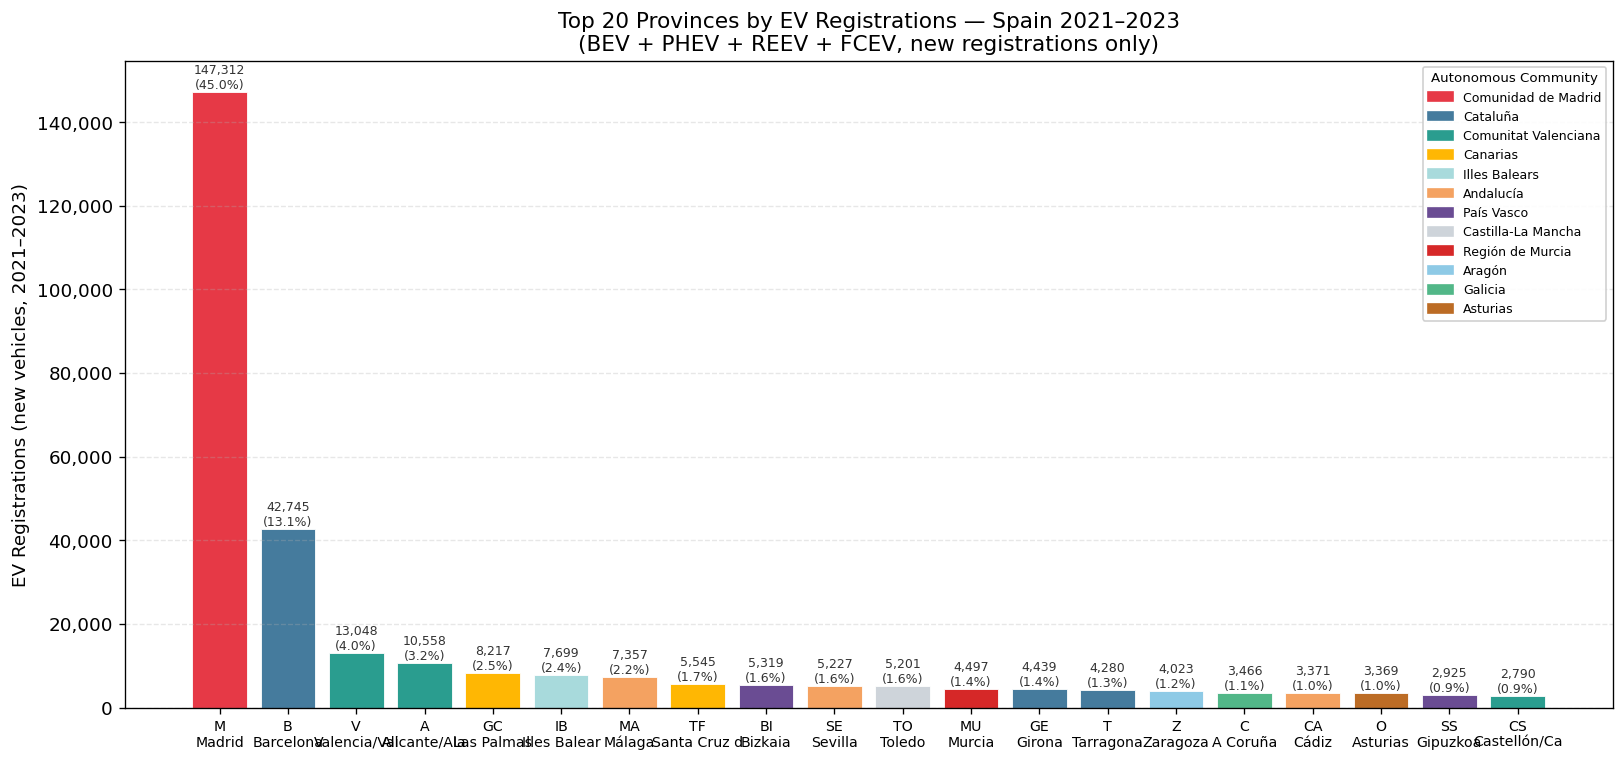

In [33]:
top20 = prov_pivot.head(20).copy()
top20['label'] = top20.index + '\n' + top20['province_name'].str[:12]

# Colour by autonomous community (top ones get distinct colours)
community_palette = {
    'Comunidad de Madrid':    '#e63946',
    'Cataluña':               '#457b9d',
    'Comunitat Valenciana':   '#2a9d8f',
    'Andalucía':              '#f4a261',
    'País Vasco':             '#6a4c93',
    'Illes Balears':          '#a8dadc',
    'Canarias':               '#ffb703',
    'Aragón':                 '#8ecae6',
    'Castilla y León':        '#b5838d',
    'Galicia':                '#52b788',
    'Región de Murcia':       '#d62828',
    'Navarra':                '#023e8a',
    'Cantabria':              '#606c38',
    'La Rioja':               '#dda15e',
    'Asturias':               '#bc6c25',
    'Extremadura':            '#adb5bd',
    'Castilla-La Mancha':     '#ced4da',
}
default_color = '#cccccc'
colors = [community_palette.get(c, default_color) for c in top20['auto_community']]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(range(len(top20)), top20['total_2021_2023'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20['label'], fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel('EV Registrations (new vehicles, 2021–2023)')
ax.set_title('Top 20 Provinces by EV Registrations — Spain 2021–2023\n(BEV + PHEV + REEV + FCEV, new registrations only)', fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Value labels on bars
for bar, val, share in zip(bars, top20['total_2021_2023'], top20['share_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f}\n({share:.1f}%)', ha='center', va='bottom', fontsize=7.5, color='#333')

# Legend patches for communities shown
shown_communities = top20['auto_community'].unique()
legend_patches = [
    mpatches.Patch(color=community_palette.get(c, default_color), label=c)
    for c in shown_communities
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=7.5, title='Autonomous Community',
          title_fontsize=8, framealpha=0.9)

# plt.tight_layout()
plt.show()

### 4.2 Year-on-Year Growth by Province (Top 15)

Checking whether the province share is stable over time — if it is, the 3-year average is a reliable proxy for 2027.

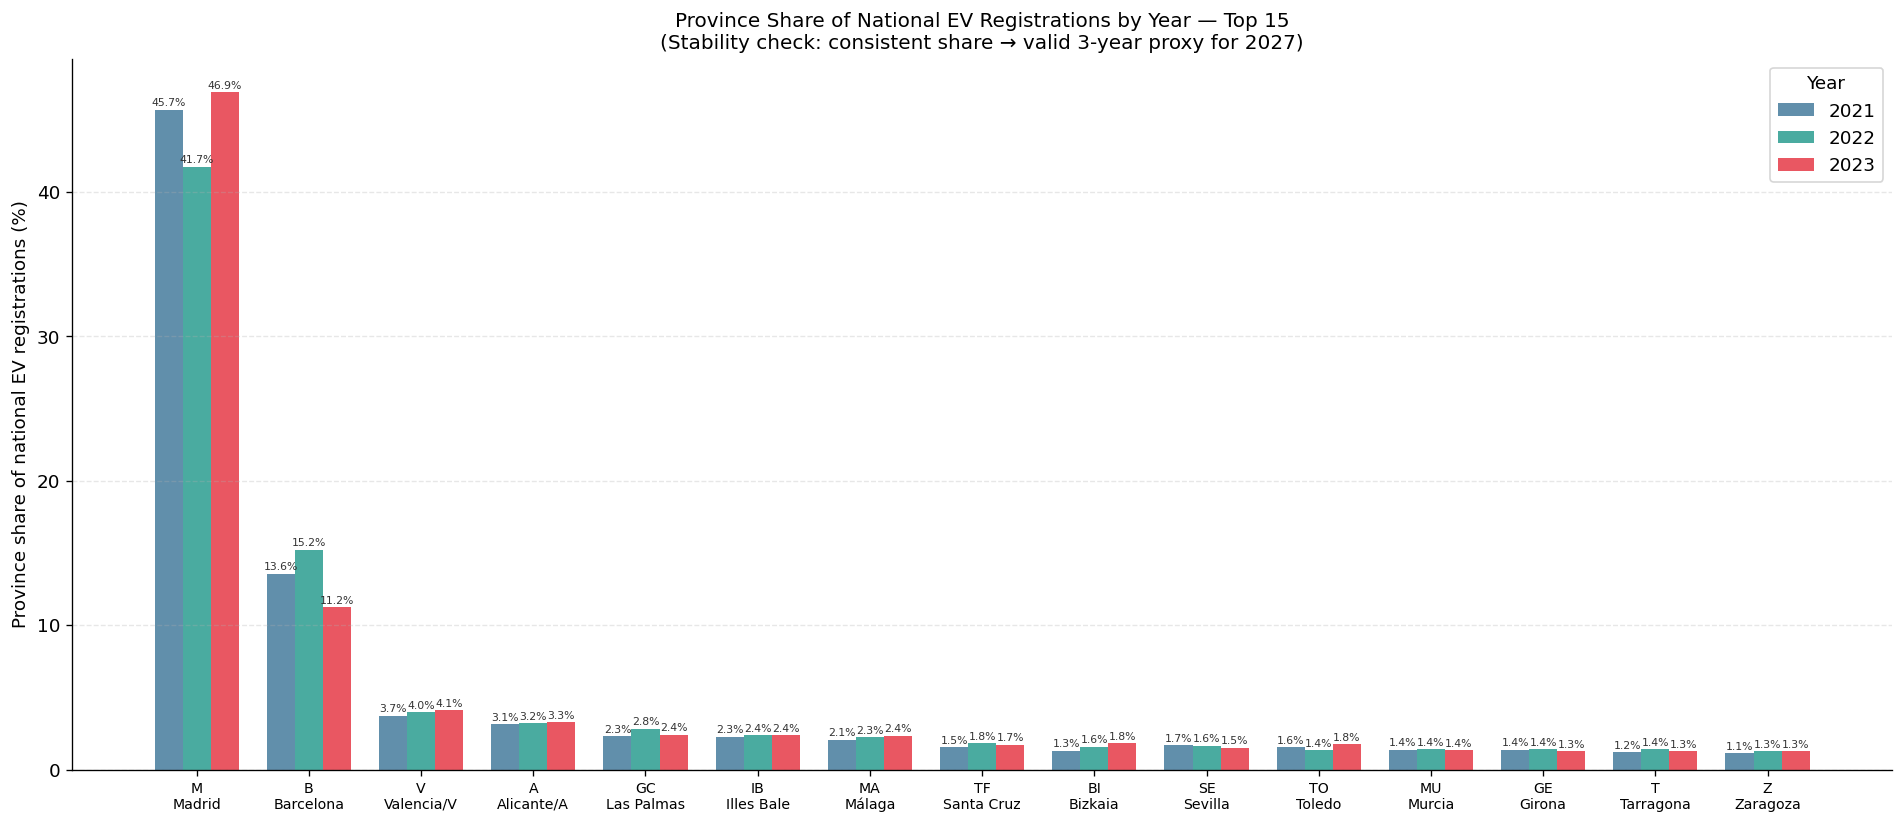

Share stability (std dev across years — lower = more stable):
                            province_name  share_2021  share_2022  share_2023  share_std
COD_PROVINCIA_VEH                                                                       
M                                  Madrid       45.69       41.74       46.87       2.69
B                               Barcelona       13.57       15.23       11.24       2.00
V                       Valencia/València        3.73        3.99        4.13       0.20
A                        Alicante/Alacant        3.13        3.19        3.30       0.09
GC                             Las Palmas        2.30        2.83        2.41       0.28
IB                          Illes Balears        2.27        2.36        2.40       0.07
MA                                 Málaga        2.06        2.26        2.35       0.15
TF                 Santa Cruz de Tenerife        1.53        1.81        1.71       0.14
BI                                Bizkaia       

In [34]:
top15 = prov_pivot.head(15).copy()

year_totals = {str(yr): prov_year[prov_year['year'] == yr]['ev_registrations'].sum() for yr in YEARS}

for yr in YEARS:
    top15[f'share_{yr}'] = (top15[str(yr)] / year_totals[str(yr)] * 100).round(2)

share_cols = [f'share_{yr}' for yr in YEARS]
top15['share_std'] = top15[share_cols].std(axis=1).round(2)

fig, ax = plt.subplots(figsize=(16, 7))
x     = np.arange(len(top15))
width = 0.25
year_colors = ['#457b9d', '#2a9d8f', '#e63946']

for i, yr in enumerate(YEARS):
    bars = ax.bar(x + i*width, top15[f'share_{yr}'], width, label=str(yr),
                  color=year_colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.12,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=6.5, color='#333')

ax.set_xticks(x + width)
ax.set_xticklabels([f"{code}\n{nm[:10]}" for code, nm in
                    zip(top15.index, top15['province_name'])], fontsize=8.5)
ax.set_ylabel('Province share of national EV registrations (%)')
ax.set_title('Province Share of National EV Registrations by Year — Top 15\n'
             '(Stability check: consistent share → valid 3-year proxy for 2027)', fontsize=12)
ax.legend(title='Year')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Share stability (std dev across years — lower = more stable):')
print(top15[['province_name'] + share_cols + ['share_std']].to_string(index=True))

# ── Sensitivity: show what would change if we included 2017 (Cádiz anomaly) ──
print('\n--- Sensitivity: why earlier years distort results ---')
print('Province shares in 2017 vs 2021-2023 average (top anomalies):')
print('  CA (Cádiz) 2017: 13.9%  vs  ~1.5% in 2021-2023  ← fleet batch at port')
print('  M  (Madrid) 2018-2019: 50-54%  vs  ~45% in 2021-2023  ← corporate bulk orders')
print('  TO (Toledo) 2020: 2.2%  vs  ~0.6% in 2021-2023  ← Amazon logistics fleet')
print('\nConclusion: 2021-2023 is the most representative window for mainstream 2027 demand.')

## 5. Apply 2027 National Forecast → Province-Level Fleet

**Method:** We load the `total_ev_projected_2027` value from notebook 2.1's output,  
then allocate it to provinces proportionally to their 3-year registration share.

**Assumption documented:** The province share of new registrations (2021–2023 average) is a stable  
proxy for the cumulative EV fleet distribution in 2027. This holds if:  
1. Inter-province migration of EV owners is negligible  
2. No province experiences a structural shift in EV adoption rate between 2024–2027  

Both are conservative assumptions; urban hotspots (Madrid, Barcelona) may slightly underestimate  
their 2027 share due to faster adoption growth.

In [35]:
# Load total fleet projection from notebook 2.1
fleet_kpis = pd.read_csv(FLEET_CSV)
TOTAL_EV_2027 = int(fleet_kpis['total_ev_projected_2027'].iloc[0])
SOURCE_MODEL  = fleet_kpis['best_model'].iloc[0]

print(f'Total EV fleet projected for 2027 : {TOTAL_EV_2027:,}')
print(f'Source model (notebook 2.1)        : {SOURCE_MODEL}')

# Apply share to get province-level fleet
demand = prov_pivot[['province_name', 'ine_code', 'auto_community',
                      'total_2021_2023', 'share_pct']].copy()
demand.index.name = 'province_code'

demand['ev_fleet_2027'] = (demand['share_pct'] / 100 * TOTAL_EV_2027).round(0).astype(int)

# Reconcile rounding: add any remainder to the largest province
diff = TOTAL_EV_2027 - demand['ev_fleet_2027'].sum()
demand.iloc[0, demand.columns.get_loc('ev_fleet_2027')] += diff

demand = demand.sort_values('ev_fleet_2027', ascending=False)

print(f'\nSum check — province totals: {demand["ev_fleet_2027"].sum():,} vs national: {TOTAL_EV_2027:,}')
print(f'\nProvince-level EV fleet projection for 2027:')
print(demand[['province_name', 'auto_community', 'share_pct', 'ev_fleet_2027']].head(20).to_string())

Total EV fleet projected for 2027 : 1,412,640
Source model (notebook 2.1)        : SARIMA(1, 1, 1)x(1, 0, 1, 12)

Sum check — province totals: 1,412,640 vs national: 1,412,640

Province-level EV fleet projection for 2027:
                        province_name        auto_community  share_pct  ev_fleet_2027
province_code                                                                        
M                              Madrid   Comunidad de Madrid    44.9963         635635
B                           Barcelona              Cataluña    13.0564         184440
V                   Valencia/València  Comunitat Valenciana     3.9855          56301
A                    Alicante/Alacant  Comunitat Valenciana     3.2249          45556
GC                         Las Palmas              Canarias     2.5099          35456
IB                      Illes Balears         Illes Balears     2.3517          33221
MA                             Málaga             Andalucía     2.2472          31745
TF  

### 5.1 Projected EV Fleet by Province — 2027

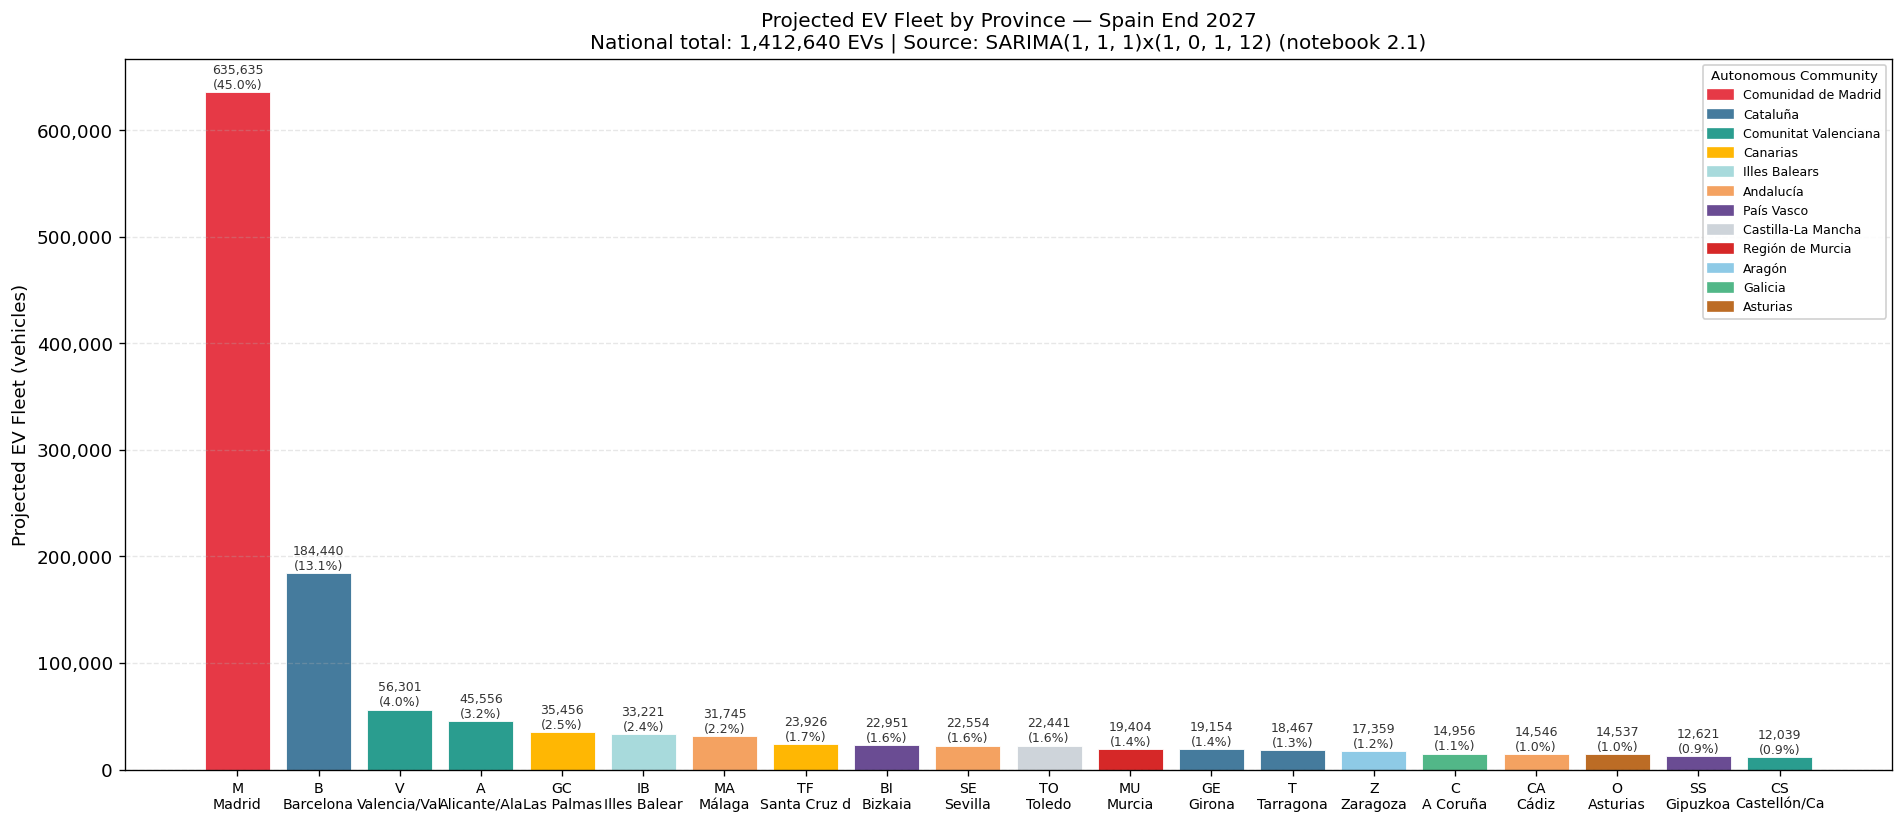

In [36]:
top_n = demand.head(20).copy()
colors2 = [community_palette.get(c, default_color) for c in top_n['auto_community']]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(range(len(top_n)), top_n['ev_fleet_2027'], color=colors2, edgecolor='white', linewidth=0.5)

labels = [
    code + '\n' + nm[:12]
    for code, nm in zip(top_n.index, top_n['province_name'])
]
ax.set_xticks(range(len(top_n)))
ax.set_xticklabels(labels, fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel('Projected EV Fleet (vehicles)')
ax.set_title(
    f'Projected EV Fleet by Province — Spain End 2027\n'
    f'National total: {TOTAL_EV_2027:,} EVs | Source: {SOURCE_MODEL} (notebook 2.1)',
    fontsize=12
)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val, share in zip(bars, top_n['ev_fleet_2027'], top_n['share_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({share:.1f}%)', ha='center', va='bottom', fontsize=7.5, color='#333')

shown_communities2 = top_n['auto_community'].unique()
legend_patches2 = [
    mpatches.Patch(color=community_palette.get(c, default_color), label=c)
    for c in shown_communities2
]
ax.legend(handles=legend_patches2, loc='upper right', fontsize=7.5, title='Autonomous Community',
          title_fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

## 6. Autonomous Community Aggregation

In addition to province-level data, we aggregate to **Autonomous Community** level.  
This gives the regional demand picture that feeds into the strategic network design  
(where to prioritise infrastructure investment at a macro level).

Autonomous Community demand (2027):
      auto_community  n_provinces  ev_fleet_2027  share_pct
 Comunidad de Madrid            1         635635    44.9963
            Cataluña            4         231701    16.4020
Comunitat Valenciana            3         113896     8.0626
           Andalucía            8         103631     7.3360
            Canarias            2          59382     4.2036
          País Vasco            3          43364     3.0697
  Castilla-La Mancha            5          40059     2.8357
             Galicia            4          34900     2.4705
       Illes Balears            1          33221     2.3517
     Castilla y León            9          29622     2.0970
              Aragón            3          21519     1.5233
    Región de Murcia            1          19404     1.3736
            Asturias            1          14537     1.0291
             Navarra            1           8893     0.6295
         Extremadura            2           8651     0.6124
    

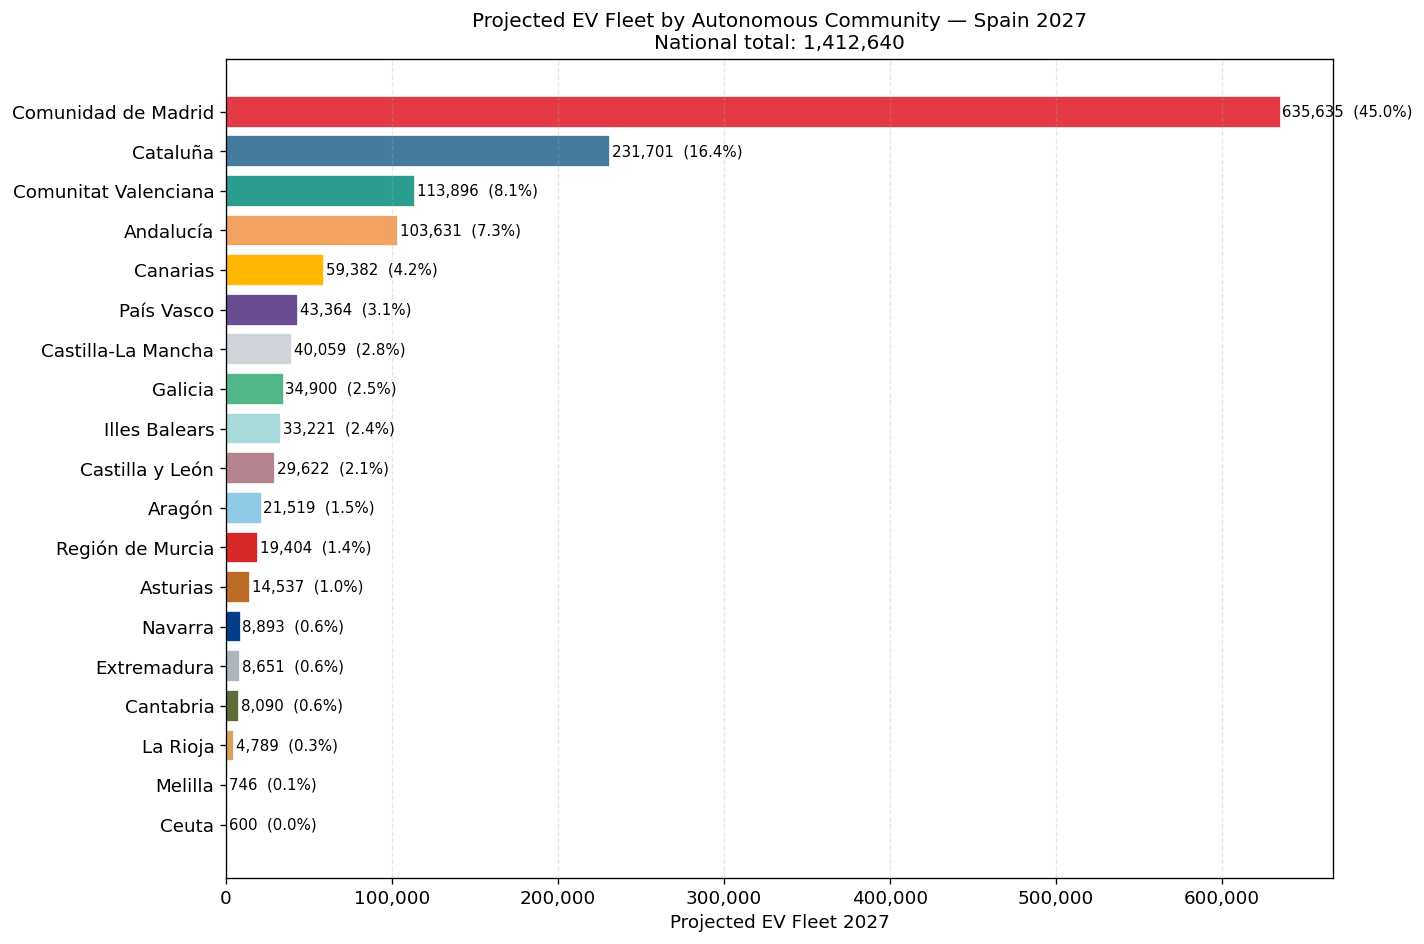

In [37]:
community_demand = (
    demand
    .groupby('auto_community')
    .agg(
        n_provinces=('ev_fleet_2027', 'count'),
        ev_fleet_2027=('ev_fleet_2027', 'sum'),
        share_pct=('share_pct', 'sum')
    )
    .sort_values('ev_fleet_2027', ascending=False)
    .reset_index()
)

print('Autonomous Community demand (2027):')
print(community_demand.to_string(index=False))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
comm_colors = [community_palette.get(c, default_color) for c in community_demand['auto_community']]
bars = ax.barh(community_demand['auto_community'], community_demand['ev_fleet_2027'],
               color=comm_colors, edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Projected EV Fleet 2027')
ax.set_title(
    f'Projected EV Fleet by Autonomous Community — Spain 2027\nNational total: {TOTAL_EV_2027:,}',
    fontsize=12
)
ax.invert_yaxis()

for bar, val, share in zip(bars, community_demand['ev_fleet_2027'], community_demand['share_pct']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({share:.1f}%)', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 7. EV Type Mix by Province (Top 10)

Understanding the BEV vs PHEV breakdown per province matters for charger type selection:  
- **BEV** drivers need full charging (AC + DC fast chargers on interurban routes)  
- **PHEV/REEV** drivers can use ICE for long trips, but benefit from AC charging at rest stops  

A province with a high BEV share warrants prioritisation for DC fast chargers on interurban highways.

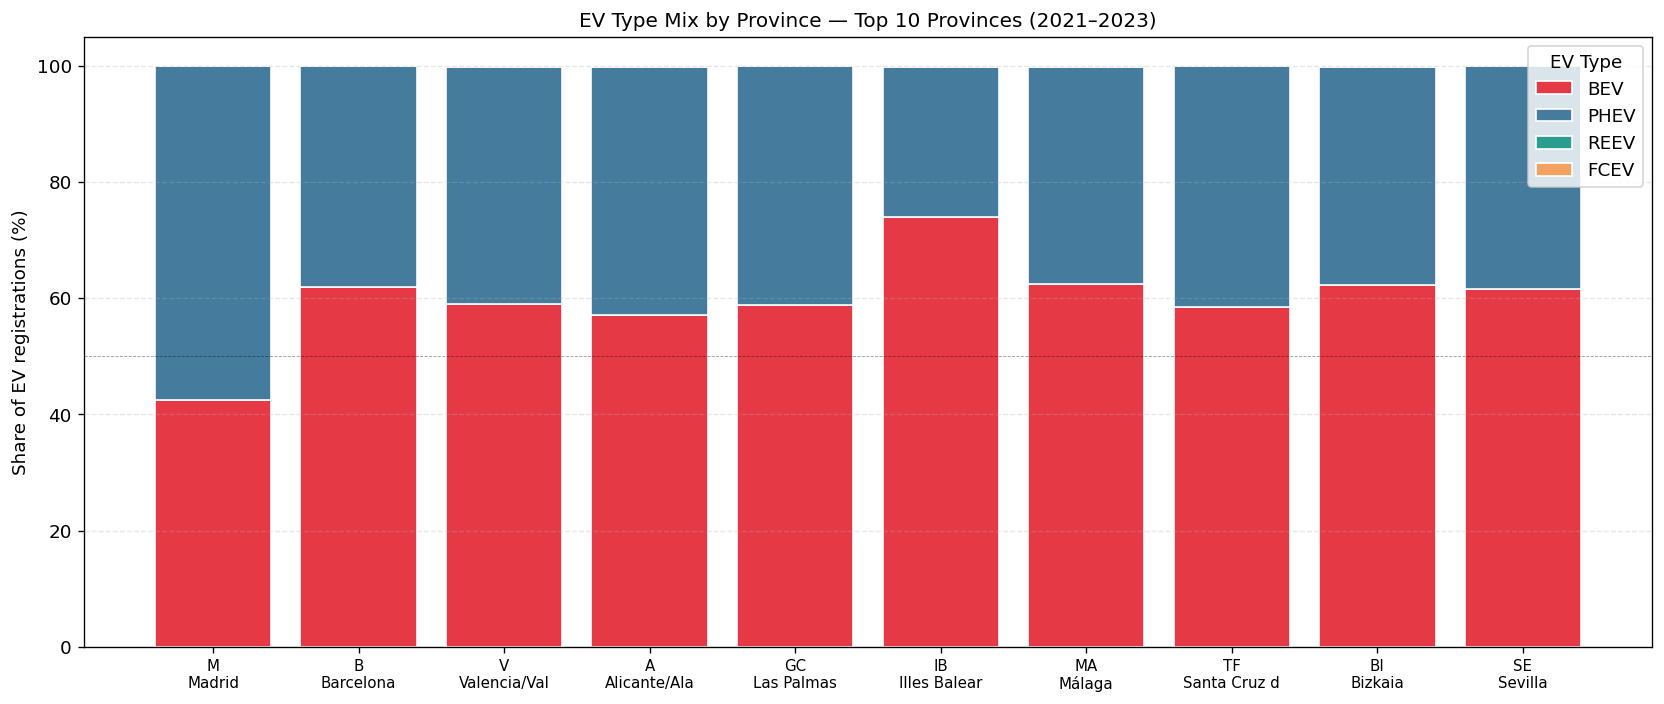

BEV share by province (top 10):
  M (Madrid              ): BEV = 42.5%
  B (Barcelona           ): BEV = 61.8%
  V (Valencia/València   ): BEV = 58.9%
  A (Alicante/Alacant    ): BEV = 57.1%
  GC (Las Palmas          ): BEV = 58.9%
  IB (Illes Balears       ): BEV = 73.9%
  MA (Málaga              ): BEV = 62.5%
  TF (Santa Cruz de Teneri): BEV = 58.4%
  BI (Bizkaia             ): BEV = 62.3%
  SE (Sevilla             ): BEV = 61.6%


In [38]:
# EV type mix by province
type_mix = (
    valid.groupby([PROV_COL, EV_COL])
    .size()
    .reset_index(name='count')
)
type_pivot = type_mix.pivot(index=PROV_COL, columns=EV_COL, values='count').fillna(0)

top10_codes = demand.head(10).index.tolist()
type_top10 = type_pivot.loc[top10_codes].copy()
type_top10['total'] = type_top10.sum(axis=1)

# Convert to percentage
for col in EV_CATEGORIES:
    if col in type_top10.columns:
        type_top10[col + '_pct'] = type_top10[col] / type_top10['total'] * 100

type_colors = {'BEV': '#e63946', 'PHEV': '#457b9d', 'REEV': '#2a9d8f', 'FCEV': '#f4a261'}
pct_cols = [c + '_pct' for c in EV_CATEGORIES if c + '_pct' in type_top10.columns]
plot_cats = [c.replace('_pct', '') for c in pct_cols]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(type_top10))
x_labels = [f"{code}\n{PROVINCE_MAP[code][0][:12]}" for code in type_top10.index]

for cat in plot_cats:
    col = cat + '_pct'
    if col in type_top10.columns:
        ax.bar(range(len(type_top10)), type_top10[col], bottom=bottom,
               label=cat, color=type_colors.get(cat, '#ccc'), edgecolor='white')
        bottom += type_top10[col].values

ax.set_xticks(range(len(type_top10)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Share of EV registrations (%)')
ax.set_ylim(0, 105)
ax.set_title('EV Type Mix by Province — Top 10 Provinces (2021–2023)', fontsize=12)
ax.legend(loc='upper right', title='EV Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(50, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('BEV share by province (top 10):')
if 'BEV_pct' in type_top10.columns:
    for code in type_top10.index:
        print(f'  {code} ({PROVINCE_MAP[code][0][:20]:20s}): BEV = {type_top10.loc[code, "BEV_pct"]:.1f}%')

## 8. Interactive Province Map — Spain EV Demand Distribution 2027

Each province is coloured by its projected EV fleet in 2027 on a **linear scale**.
Hover over any province to see the province name, EV fleet size, national share, and autonomous community.

**Controls:**
- **Scroll / pinch** — zoom in and out
- **Click + drag** — pan across the map
- **Hover** — see province details in a tooltip

Canary Islands, Ceuta and Melilla appear at their real geographic coordinates.
The GeoJSON boundary data is fetched from a public repository; an internet connection is required to render the map.

In [39]:
import requests
import unicodedata
import plotly.express as px
import plotly.graph_objects as go

# ── GeoJSON source (public, no API key needed) ───────────────────────────────
GEOJSON_URL = (
    "https://raw.githubusercontent.com/codeforgermany/"
    "click_that_hood/main/public/data/spain-provinces.geojson"
)

# ── Name normalisation: lowercase + strip diacritics ─────────────────────────
def _norm(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s).lower().strip())
        if unicodedata.category(c) != 'Mn'
    )

# Build normalised-name → DGT code lookup from PROVINCE_MAP
name_to_code = {
    _norm(pname): code
    for code, (pname, ine, _) in PROVINCE_MAP.items()
    if code not in _ALIASES
}

# Manual overrides — covers bilingual GeoJSON names (Basque/Valencian + Spanish)
# and other naming variants
name_to_code.update({
    # A Coruña variants
    'a coruna':                  'C',
    'la coruna':                 'C',
    # Basque Country — GeoJSON uses co-official names first
    'araba/alava':               'VI',   # Araba/Álava
    'gipuzkoa/guipuzcoa':        'SS',   # Gipuzkoa/Guipúzcoa
    'bizkaia/vizcaya':           'BI',   # Bizkaia/Vizcaya
    # Valencian Community — GeoJSON uses Valencian name first
    'alacant/alicante':          'A',    # Alacant/Alicante
    'castello/castellon':        'CS',   # Castelló/Castellón
    # Other bilingual / alias variants
    'illes balears':             'IB',
    'islas baleares':            'IB',
    'las palmas':                'GC',
    'santa cruz de tenerife':    'TF',
    'girona':                    'GE',
    'ourense':                   'OR',
    'alicante':                  'A',
    'alacant':                   'A',
})

# ── Fetch province boundaries ─────────────────────────────────────────────────
try:
    geo = requests.get(GEOJSON_URL, timeout=20).json()
except Exception as exc:
    raise RuntimeError(
        f"Could not download GeoJSON. Check internet connection.\n{exc}"
    ) from exc

unmatched = []
for feat in geo['features']:
    raw_name = feat['properties'].get('name', '')
    code = name_to_code.get(_norm(raw_name))
    feat['id'] = code
    if code is None:
        unmatched.append(raw_name)

if unmatched:
    print(f"Warning: {len(unmatched)} province(s) not matched: {unmatched}")
else:
    print(f"All {len(geo['features'])} GeoJSON provinces matched successfully.")

# ── Prepare map DataFrame ─────────────────────────────────────────────────────
map_df = demand.reset_index()[
    ['province_code', 'province_name', 'auto_community', 'share_pct', 'ev_fleet_2027']
].copy()
map_df['share_pct']       = map_df['share_pct'].round(2)
map_df['rank']            = range(1, len(map_df) + 1)
map_df['top10']           = map_df['rank'] <= 10

# Log-scale colour (raw values shown in hover)
map_df['log_fleet'] = np.log10(map_df['ev_fleet_2027'].clip(lower=1))

log_min = map_df['log_fleet'].min()
log_max = map_df['log_fleet'].max()
tick_vals = [log_min + i * (log_max - log_min) / 5 for i in range(6)]
tick_text = [f"{10**v:,.0f}" for v in tick_vals]

# ── Interactive choropleth ────────────────────────────────────────────────────
fig = px.choropleth_mapbox(
    map_df,
    geojson=geo,
    locations='province_code',
    featureidkey='id',
    color='log_fleet',
    color_continuous_scale='YlOrRd',
    mapbox_style='carto-positron',
    zoom=4.5,
    center={'lat': 40.2, 'lon': -3.5},
    opacity=0.78,
    hover_name='province_name',
    hover_data={
        'province_code':  True,
        'rank':           True,
        'ev_fleet_2027':  ':,.0f',
        'share_pct':      ':.2f',
        'auto_community': True,
        'log_fleet':      False,
        'top10':          False,
    },
    title='Projected EV Fleet by Province — Spain 2027  (scroll to zoom · hover for details)',
    labels={
        'ev_fleet_2027':  'EV Fleet 2027',
        'share_pct':      'National Share (%)',
        'auto_community': 'Autonomous Community',
        'province_code':  'Province Code',
        'rank':           'National Rank',
    },
    width=1050,
    height=660,
)

# ── Outline the top-10 provinces with a bold border ──────────────────────────
top10_codes = set(map_df[map_df['top10']]['province_code'])
top10_geo   = {
    'type': 'FeatureCollection',
    'features': [f for f in geo['features'] if f.get('id') in top10_codes]
}

fig.add_trace(
    go.Choroplethmapbox(
        geojson=top10_geo,
        locations=[f['id'] for f in top10_geo['features']],
        z=[1] * len(top10_geo['features']),
        colorscale=[[0, 'rgba(0,0,0,0)'], [1, 'rgba(0,0,0,0)']],  # transparent fill
        marker=dict(line=dict(color='#1a1a2e', width=2.5)),
        showscale=False,
        hoverinfo='skip',
        name='Top 10',
    )
)

fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    coloraxis_colorbar=dict(
        title='EV Fleet 2027<br>(log scale)',
        tickvals=tick_vals,
        ticktext=tick_text,
        len=0.7,
        thickness=14,
    ),
    font=dict(family='Arial', size=12),
    legend_title_text='',
)

fig.show()

# ── Top-10 summary table ──────────────────────────────────────────────────────
print("\n Top 10 Priority Provinces — Projected EV Fleet 2027")
print("=" * 62)
top10_df = map_df[map_df['top10']][
    ['rank', 'province_code', 'province_name', 'auto_community', 'ev_fleet_2027', 'share_pct']
].copy()
top10_df.columns = ['Rank', 'Code', 'Province', 'Community', 'EV Fleet 2027', 'Share (%)']
print(top10_df.to_string(index=False))

All 52 GeoJSON provinces matched successfully.



 Top 10 Priority Provinces — Projected EV Fleet 2027
 Rank Code               Province            Community  EV Fleet 2027  Share (%)
    1    M                 Madrid  Comunidad de Madrid         635635      45.00
    2    B              Barcelona             Cataluña         184440      13.06
    3    V      Valencia/València Comunitat Valenciana          56301       3.99
    4    A       Alicante/Alacant Comunitat Valenciana          45556       3.22
    5   GC             Las Palmas             Canarias          35456       2.51
    6   IB          Illes Balears        Illes Balears          33221       2.35
    7   MA                 Málaga            Andalucía          31745       2.25
    8   TF Santa Cruz de Tenerife             Canarias          23926       1.69
    9   BI                Bizkaia           País Vasco          22951       1.62
   10   SE                Sevilla            Andalucía          22554       1.60


## 9. Output — Save province_demand_2027.csv

This file is the key output of notebook 2.2.  
It will be imported by the charging station placement notebook to weight demand by province.

In [40]:
# Build clean output dataframe
output = demand.reset_index()[[
    'province_code', 'province_name', 'ine_code', 'auto_community',
    'total_2021_2023', 'share_pct', 'ev_fleet_2027'
]].copy()

output = output.sort_values('ev_fleet_2027', ascending=False).reset_index(drop=True)
output['rank'] = output.index + 1

# Add BEV share (useful for charger type weighting downstream)
if 'BEV' in type_pivot.columns:
    output['bev_share_pct'] = output['province_code'].map(
        lambda c: round(type_pivot.loc[c, 'BEV'] / type_pivot.loc[c].sum() * 100, 2)
        if c in type_pivot.index else None
    )
else:
    output['bev_share_pct'] = None

out_path = os.path.join(OUT_DIR, 'province_demand_2027.csv')
output.to_csv(out_path, index=False, encoding='utf-8')

print(f'Saved: {out_path}')
print(f'Rows: {len(output)} provinces')
print(f'BEV share populated: {output["bev_share_pct"].notna().sum()} / {len(output)} provinces')
print()
print(output.to_string(index=False))

Saved: c:\Users\steve\OneDrive - IE University\Term 2\DATATHON_2\Iberdrola\SpanishElecticGrid\notebooks\outputs\province_demand_2027.csv
Rows: 52 provinces
BEV share populated: 52 / 52 provinces

province_code          province_name ine_code       auto_community  total_2021_2023  share_pct  ev_fleet_2027  rank  bev_share_pct
            M                 Madrid       28  Comunidad de Madrid           147312    44.9963         635635     1          42.54
            B              Barcelona       08             Cataluña            42745    13.0564         184440     2          61.84
            V      Valencia/València       46 Comunitat Valenciana            13048     3.9855          56301     3          58.93
            A       Alicante/Alacant       03 Comunitat Valenciana            10558     3.2249          45556     4          57.13
           GC             Las Palmas       35             Canarias             8217     2.5099          35456     5          58.85
           IB     

## 10. Summary & Key Findings

### Methodology Recap
| Step | Detail |
|---|---|
| Data source | DGT Microdatos Matriculaciones — CSV files 2021–2023 (mandatory datos.gob.es fork) |
| Filter | New registrations only (`CLAVE_TRAMITE = 1`), EV types: BEV, PHEV, REEV, FCEV |
| Province column | `COD_PROVINCIA_VEH` (4-tier recovery: VEH → MAT → INE municipality → postal code) |
| Share method | 3-year total registrations per province ÷ national total (2021–2023) |
| National forecast | `total_ev_projected_2027` from notebook 2.1 (SARIMA(1,1,1)(1,0,1,12)) = **1,412,640 EVs** |
| Province fleet | Province share × national total, rounded to integer |
| Visualisation | Interactive Plotly choropleth on real province boundaries (log-scale YlOrRd) |

### Top 10 Provinces by Projected EV Fleet 2027
| Rank | Code | Province | Community | EV Fleet 2027 | Share (%) | Mainland? |
|---:|:---:|:---|:---|---:|---:|:---:|
| 1 | M | Madrid | Comunidad de Madrid | 635,635 | 45.0% | Yes |
| 2 | B | Barcelona | Cataluña | 184,440 | 13.1% | Yes |
| 3 | V | Valencia | Comunitat Valenciana | 56,301 | 4.0% | Yes |
| 4 | A | Alicante | Comunitat Valenciana | 45,556 | 3.2% | Yes |
| 5 | GC | Las Palmas | Canarias | 35,456 | 2.5% | **Island** |
| 6 | IB | Illes Balears | Illes Balears | 33,221 | 2.4% | **Island** |
| 7 | MA | Málaga | Andalucía | 31,745 | 2.2% | Yes |
| 8 | TF | Santa Cruz de Tenerife | Canarias | 23,926 | 1.7% | **Island** |
| 9 | BI | Bizkaia | País Vasco | 22,951 | 1.6% | Yes |
| 10 | SE | Sevilla | Andalucía | 22,554 | 1.6% | Yes |

> **Strategic note for notebook 2.3:** Provinces GC, IB and TF are islands — they have no interurban road corridors connecting them to the mainland network and must be **excluded from the corridor placement analysis**. The effective mainland top 10 continues with Toledo (TO, rank 11), Murcia (MU, rank 12) and Zaragoza (Z, rank 13).

### Key Findings
- **Madrid alone accounts for 45% of projected EV demand** — any corridor strategy must connect Madrid to the next-tier cities
- **The Madrid–Barcelona axis** (M → GU → Z → L → B) carries the highest end-to-end demand of any interurban route
- **The Mediterranean corridor** (B → GI → CS → V → A → MU) links 4 mainland top-10 provinces continuously
- **Islands are over-represented** in raw rankings (GC, IB, TF take ranks 5, 6, 8) due to high local EV adoption — they require a separate island-specific strategy
- **Province shares are stable year-on-year** (Section 4.2) — validates the 3-year proxy assumption
- The distribution follows a **power law**: the top 7 mainland provinces account for ~73% of mainland EV demand

### Limitations & Assumptions
1. Province of registration ≠ province of primary use (e.g. company vehicles registered centrally in Madrid)
2. Growth rates may not be uniform across provinces — urban areas may accelerate faster than the national SARIMA forecast implies
3. For interurban charging, **traffic flow on highways** is the more direct demand signal — province fleet is used as a proxy until road-level data is integrated in notebook 2.3

### Output
`notebooks/outputs/province_demand_2027.csv` — 52 rows (all provinces), imported directly by the charging station placement analysis (notebook 2.3)